In [1]:
!pip install folium

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [3]:

df = pd.read_csv(r'C:\Users\kisho\Downloads\ipl-analysis\data\matches_data.csv')
print(df.shape)
print(df.columns.tolist())

(1169, 23)
['match_id', 'season_id', 'balls_per_over', 'city', 'match_date', 'event_name', 'match_number', 'gender', 'match_type', 'format', 'overs', 'season', 'team_type', 'venue', 'toss_winner', 'team1', 'team2', 'toss_decision', 'match_winner', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'result']


In [4]:
df['venue'] = df['venue'].str.strip()

venue_fixes = {
    # PCA Stadium
    'Punjab Cricket Association Stadium, Mohali': 'Punjab Cricket Association Stadium',
    'Punjab Cricket Association IS Bindra Stadium': 'Punjab Cricket Association Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali': 'Punjab Cricket Association Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh': 'Punjab Cricket Association Stadium',
    # MA Chidambaram
    'MA Chidambaram Stadium, Chepauk': 'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai': 'MA Chidambaram Stadium',
    # ACA-VDCA
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium': 'ACA-VDCA Stadium',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam': 'ACA-VDCA Stadium',
    # DY Patil
    'Dr DY Patil Sports Academy, Mumbai': 'Dr DY Patil Sports Academy',
    # Narendra Modi
    'Sardar Patel Stadium, Motera': 'Narendra Modi Stadium',
    'Narendra Modi Stadium, Ahmedabad': 'Narendra Modi Stadium',
    # Others
    'Sawai Mansingh Stadium, Jaipur': 'Sawai Mansingh Stadium',
    'Zayed Cricket Stadium, Abu Dhabi': 'Sheikh Zayed Stadium',
    'Arun Jaitley Stadium, Delhi': 'Arun Jaitley Stadium',
    'Brabourne Stadium, Mumbai': 'Brabourne Stadium',
    'Eden Gardens, Kolkata': 'Eden Gardens',
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
    'Rajiv Gandhi International Stadium, Uppal': 'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad': 'Rajiv Gandhi International Stadium',
    'Maharashtra Cricket Association Stadium, Pune': 'Maharashtra Cricket Association Stadium',
    'Subrata Roy Sahara Stadium': 'Maharashtra Cricket Association Stadium',
    'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow': 'Ekana Cricket Stadium',
    'Barsapara Cricket Stadium, Guwahati': 'Barsapara Cricket Stadium',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala': 'Himachal Pradesh Cricket Association Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur': 'Maharaja Yadavindra Singh International Cricket Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh': 'Maharaja Yadavindra Singh International Cricket Stadium',
    'Vidarbha Cricket Association Stadium, Jamtha': 'Vidarbha Cricket Association Stadium',
    'JSCA International Stadium Complex': 'JSCA International Stadium Complex',
    'SuperSport Park': 'Supersport Park',
    'OUTsurance Oval': 'Outsurance Oval',
    'Feroz Shah Kotla': 'Arun Jaitley Stadium',
    'M.Chinnaswamy Stadium': 'M Chinnaswamy Stadium',
    'M Chinnaswamy Stadium, Bengaluru': 'M Chinnaswamy Stadium',
}

df['venue'] = df['venue'].replace(venue_fixes)
print(df['venue'].unique())
print(f"Total unique venues: {df['venue'].nunique()}")

['M Chinnaswamy Stadium' 'Rajiv Gandhi International Stadium'
 'Maharashtra Cricket Association Stadium'
 'Saurashtra Cricket Association Stadium' 'Holkar Cricket Stadium'
 'Wankhede Stadium' 'Eden Gardens' 'Arun Jaitley Stadium'
 'Punjab Cricket Association Stadium' 'Green Park'
 'MA Chidambaram Stadium' 'Sawai Mansingh Stadium' 'ACA-VDCA Stadium'
 'Sheikh Zayed Stadium' 'Dubai International Cricket Stadium'
 'Sharjah Cricket Stadium' 'Narendra Modi Stadium' 'Brabourne Stadium'
 'Dr DY Patil Sports Academy' 'Ekana Cricket Stadium'
 'Barsapara Cricket Stadium'
 'Himachal Pradesh Cricket Association Stadium'
 'Maharaja Yadavindra Singh International Cricket Stadium' 'Newlands'
 "St George's Park" 'Kingsmead' 'Supersport Park' 'Buffalo Park'
 'New Wanderers Stadium' 'De Beers Diamond Oval' 'Outsurance Oval'
 'Barabati Stadium' 'Vidarbha Cricket Association Stadium' 'Nehru Stadium'
 'Shaheed Veer Narayan Singh International Stadium'
 'JSCA International Stadium Complex']
Total unique venu

In [5]:
#sanity check
print(df['toss_winner'].unique())
print(df['match_winner'].unique())
print(df['toss_decision'].unique())

['Royal Challengers Bengaluru' 'Rising Pune Supergiants'
 'Kolkata Knight riders' 'Punjab Kings' 'Sun risers Hyderabad'
 'Mumbai Indians' 'Gujarat Lions' 'Delhi Capitals' 'Chennai Super Kings'
 'Rajasthan Royals' 'Gujarat Titans' 'Lucknow Super Giants'
 'Kochi tuskers Kerala' 'Pune warriors']
['Kolkata Knight riders' 'Sun risers Hyderabad' 'Rising Pune Supergiants'
 'Punjab Kings' 'Royal Challengers Bengaluru' 'Mumbai Indians'
 'Delhi Capitals' 'Gujarat Lions' 'Chennai Super Kings' 'Rajasthan Royals'
 'Gujarat Titans' 'Lucknow Super Giants' 'Pune warriors'
 'Kochi tuskers Kerala']
['field' 'bat']


In [6]:
df['toss_match_win'] = df['toss_winner'] == df['match_winner']
win_rate = df['toss_match_win'].mean()
print(f"Toss winner wins match: {win_rate:.1%}")

Toss winner wins match: 51.6%


In [7]:
venue_toss = df.groupby(['venue', 'toss_decision']).agg(
    matches=('toss_match_win', 'count'),
    toss_wins=('toss_match_win', 'sum')
).reset_index()

venue_toss['win_pct'] = (venue_toss['toss_wins'] 
                         / venue_toss['matches'] * 100).round(1)

# Filter to venues with 10+ matches for reliability
top_venues = df['venue'].value_counts()
top_venues = top_venues[top_venues >= 10].index
venue_toss = venue_toss[venue_toss['venue'].isin(top_venues)]

print(venue_toss.sort_values('win_pct', ascending=False).head(10))

                                                venue toss_decision  matches  \
64                                    Supersport Park         field        6   
34  Maharaja Yadavindra Singh International Cricke...           bat        4   
20                              Ekana Cricket Stadium         field       16   
55                             Sawai Mansingh Stadium         field       37   
19                              Ekana Cricket Stadium           bat        6   
59                            Sharjah Cricket Stadium         field       20   
36            Maharashtra Cricket Association Stadium           bat       19   
61                               Sheikh Zayed Stadium         field       19   
28                                          Kingsmead           bat       10   
29                                          Kingsmead         field        5   

    toss_wins  win_pct  
64          5     83.3  
34          3     75.0  
20         11     68.8  
55         25     6

In [8]:
## Key finding 1
#Winning the toss only translates to a match win 51.6% of the time 
#barely better than chance. This suggests the toss is less influential
#than popular opinion suggests.


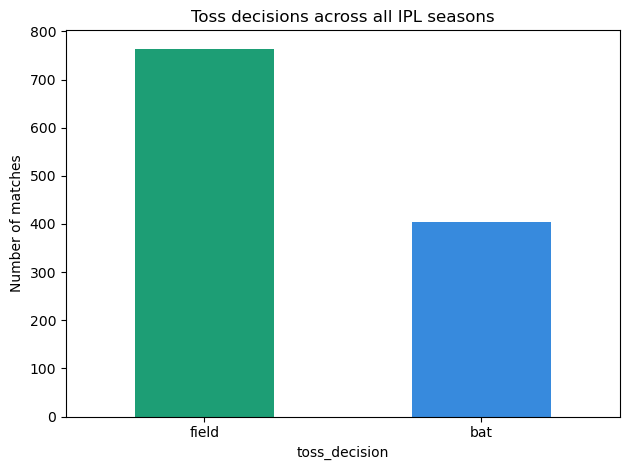

In [9]:
decision_counts = df['toss_decision'].value_counts()
decision_counts.plot(kind='bar', color=['#1D9E75','#378ADD'])
plt.title('Toss decisions across all IPL seasons')
plt.ylabel('Number of matches')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('toss_decisions.png', dpi=150)
plt.show()

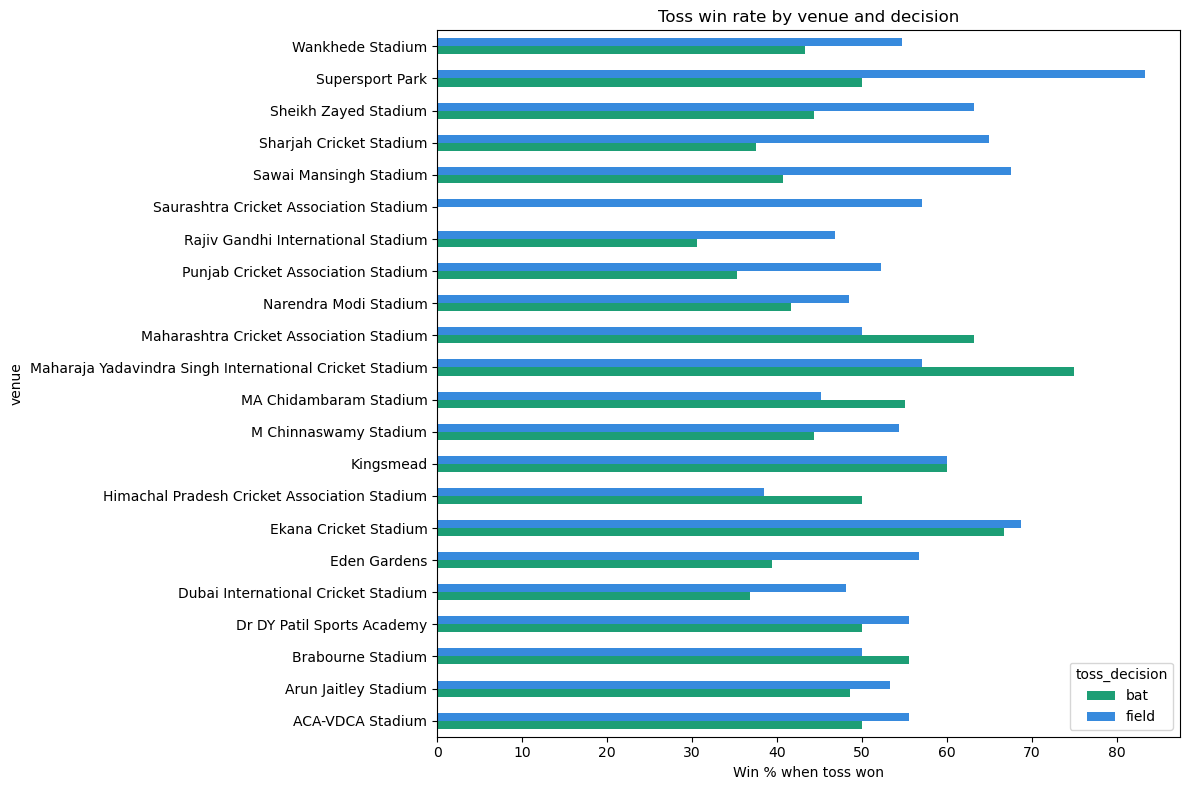

In [10]:
pivot = venue_toss.pivot(index='venue', 
                          columns='toss_decision', 
                          values='win_pct')
pivot.plot(kind='barh', figsize=(12, 8), 
           color=['#1D9E75','#378ADD'])
plt.xlabel('Win % when toss won')
plt.title('Toss win rate by venue and decision')
plt.tight_layout()
plt.savefig('venue_toss_winrate.png', dpi=150)
plt.show()

In [11]:
venue_coords = {
    'M Chinnaswamy Stadium': (12.9789, 77.5993),
    'Rajiv Gandhi International Stadium': (17.4040, 78.5516),
    'Maharashtra Cricket Association Stadium': (18.6488, 73.7254),
    'Saurashtra Cricket Association Stadium': (22.2920, 70.7823),
    'Holkar Cricket Stadium': (22.7196, 75.8577),
    'Wankhede Stadium': (18.9388, 72.8252),
    'Eden Gardens': (22.5645, 88.3433),
    'Feroz Shah Kotla': (28.6368, 77.2448),
    'Arun Jaitley Stadium': (28.6368, 77.2448),
    'Punjab Cricket Association Stadium': (30.6814, 76.8154),
    'Green Park': (26.4637, 80.3290),
    'MA Chidambaram Stadium': (13.0628, 80.2796),
    'Sawai Mansingh Stadium': (26.9124, 75.8040),
    'ACA-VDCA Stadium': (17.7231, 83.2032),
    'Sheikh Zayed Stadium': (24.4358, 54.4749),
    'Dubai International Cricket Stadium': (25.0387, 55.2219),
    'Sharjah Cricket Stadium': (25.3315, 55.3894),
    'Narendra Modi Stadium': (23.0900, 72.0847),
    'Brabourne Stadium': (18.9322, 72.8264),
    'Dr DY Patil Sports Academy': (19.0435, 73.0169),
    'Ekana Cricket Stadium': (26.8505, 80.9462),
    'Barsapara Cricket Stadium': (26.1445, 91.7362),
    'Himachal Pradesh Cricket Association Stadium': (32.2190, 76.3234),
    'Maharaja Yadavindra Singh International Cricket Stadium': (30.6942, 76.7521),
    'Vidarbha Cricket Association Stadium': (21.1762, 79.0077),
    'JSCA International Stadium Complex': (23.3441, 85.3096),
    'Newlands': (-33.9044, 18.4244),
    "St George'S Park": (-33.9608, 25.6022),
    'Kingsmead': (-29.8587, 31.0218),
    'Supersport Park': (-25.7479, 28.2293),
    'Buffalo Park': (-32.9591, 27.8774),
    'New Wanderers Stadium': (-26.1714, 28.0544),
    'De Beers Diamond Oval': (-28.7282, 24.7499),
    'Outsurance Oval': (-29.1078, 26.2619),
    'Nehru Stadium': (11.0017, 76.9673),
    'Barabati Stadium': (20.4625, 85.8830),
    'Shaheed Veer Narayan Singh International Stadium': (21.2787, 81.6736),
}

In [13]:
m = folium.Map(location=[20.5937, 78.9629], zoom_start=5)

for venue, (lat, lon) in venue_coords.items():
    subset = df[df['venue'] == venue]
    if len(subset) == 0:
        continue
    
    top_decision = subset['toss_decision'].mode()[0]
    win_pct = subset['toss_match_win'].mean() * 100
    total = len(subset)
    color = 'green' if top_decision == 'field' else 'blue'
    
    folium.CircleMarker(
        location=[lat, lon],
        radius=8,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{venue}</b><br>"
            f"Matches: {total}<br>"
            f"Preferred toss: {top_decision}<br>"
            f"Toss win rate: {win_pct:.1f}%",
            max_width=200
        ),
        tooltip=f"{venue} ({win_pct:.1f}%)"
    ).add_to(m)

m.save('ipl_venues.html')
print("Map saved! Open ipl_venues.html in your browser.")

Map saved! Open ipl_venues.html in your browser.


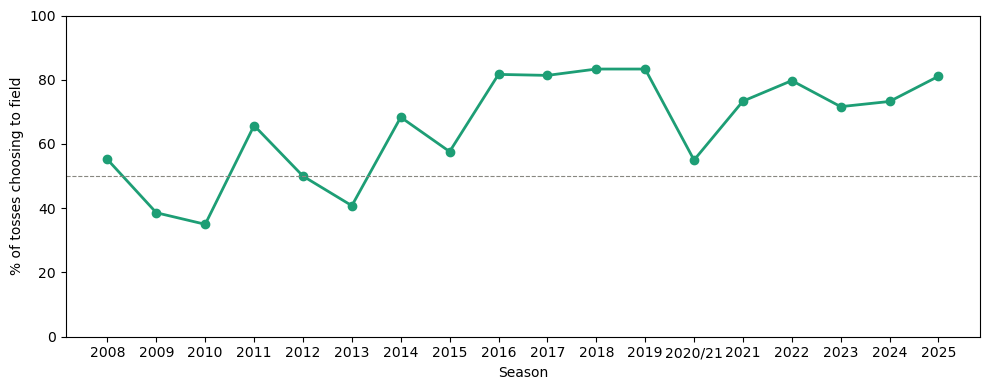

In [14]:
season_trend = df.groupby('season')['toss_decision'].apply(
    lambda x: (x == 'field').mean() * 100
).reset_index()
season_trend.columns = ['season', 'field_pct']

plt.figure(figsize=(10, 4))
plt.plot(season_trend['season'], season_trend['field_pct'], 
         marker='o', color='#1D9E75', linewidth=2)
plt.axhline(50, linestyle='--', color='#888780', linewidth=0.8)
plt.xlabel('Season')
plt.ylabel('% of tosses choosing to field')
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('toss_trend.png', dpi=500)

In [ ]:
The trend in choosing to field has been increasing gradually. 
The sudden "dip" that you see in 2020/21 season is because of the season being conducted in UAE due to COVID-19
#UAE pitches are often very dry condition making it easy for bowling later.

In [15]:
venue_advantage = df.groupby('venue')['toss_match_win'].agg(['mean', 'count'])
venue_advantage['mean'] = (venue_advantage['mean'] * 100).round(1)
venue_advantage.columns = ['win_pct', 'matches']

In [16]:
venue_advantage = venue_advantage[venue_advantage['matches'] >= 25]

In [17]:
decision_analysis = df.groupby(['venue', 'toss_decision'])['toss_match_win'].mean().unstack()
decision_analysis = (decision_analysis * 100).round(1)

In [18]:
venue_counts = df['venue'].value_counts()
valid_venues = venue_counts[venue_counts >= 35].index
decision_analysis_filtered = decision_analysis.loc[valid_venues]

In [19]:
top_advantage = venue_advantage.sort_values(by='win_pct', ascending=False).head(5)
least_advantage = venue_advantage.sort_values(by='win_pct').head(5)

In [20]:
print(top_advantage) #venues where the toss winning teams proceeded to win the match more often

                                         win_pct  matches
venue                                                    
Sharjah Cricket Stadium                     57.1       28
Sawai Mansingh Stadium                      56.2       64
Maharashtra Cricket Association Stadium     54.9       51
Sheikh Zayed Stadium                        54.1       37
Dr DY Patil Sports Academy                  54.1       37


In [21]:
print(least_advantage) #venues where winning the toss was not an advantage

                                     win_pct  matches
venue                                                
Rajiv Gandhi International Stadium      39.8       83
Dubai International Cricket Stadium     43.5       46
Narendra Modi Stadium                   46.7       45
Punjab Cricket Association Stadium      47.5       61
MA Chidambaram Stadium                  50.5       91


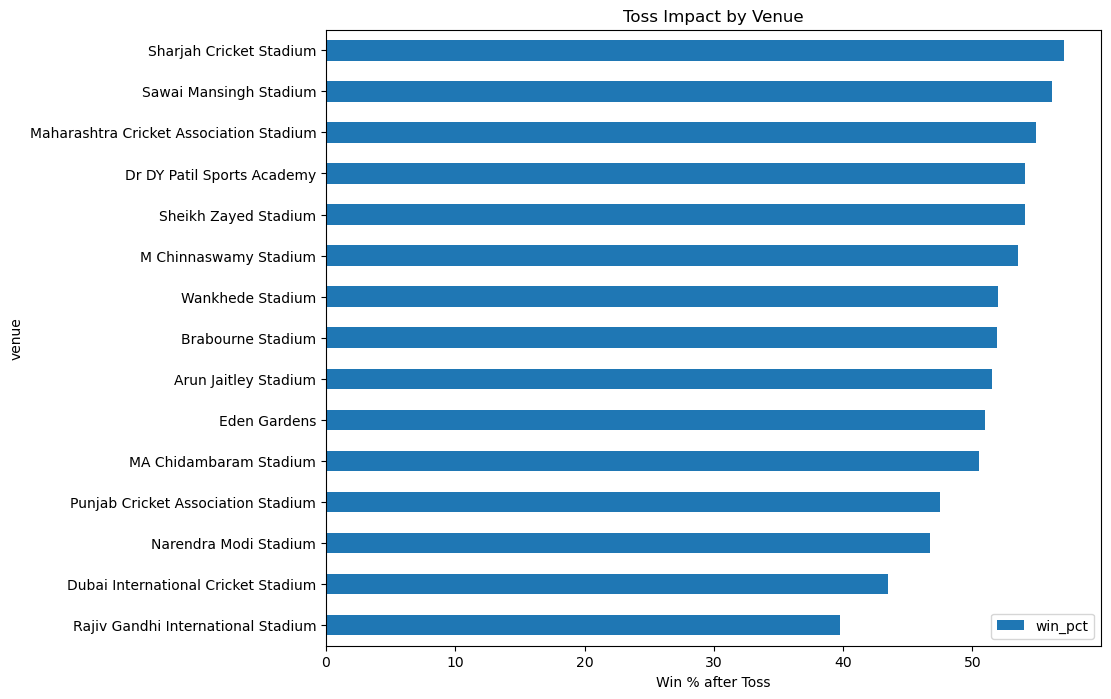

In [22]:
import matplotlib.pyplot as plt

venue_advantage.sort_values('win_pct').plot(
    kind='barh', y='win_pct', figsize=(10,8)
)
plt.title("Toss Impact by Venue")
plt.xlabel("Win % after Toss")
plt.show()

In [23]:
from scipy.stats import ttest_1samp

stat, p = ttest_1samp(df['toss_match_win'], 0.5)
print(p)

0.27936629275803687


In [24]:
print(decision_analysis_filtered) 
# % of teams that chose a decision(to bat/to field) and went on to win the match.
# for example 44.4% of teams who chose batting won in M chinnaswamy stadium.

toss_decision                             bat  field
venue                                               
Wankhede Stadium                         43.3   54.7
Eden Gardens                             39.4   56.7
M Chinnaswamy Stadium                    44.4   54.4
Arun Jaitley Stadium                     48.6   53.3
MA Chidambaram Stadium                   55.1   45.2
Rajiv Gandhi International Stadium       30.6   46.8
Sawai Mansingh Stadium                   40.7   67.6
Punjab Cricket Association Stadium       35.3   52.3
Maharashtra Cricket Association Stadium  63.2   50.0
Dubai International Cricket Stadium      36.8   48.1
Narendra Modi Stadium                    41.7   48.5
Dr DY Patil Sports Academy               50.0   55.6
Sheikh Zayed Stadium                     44.4   63.2


In [25]:
filtered_df = df[df['venue'].isin(valid_venues)]
decision_pct = (
    filtered_df.groupby(['venue', 'toss_decision'])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum() * 100)
    .unstack()
    .round(1)
)
print(decision_pct)
# % of toss decision taken by teams in that venue
# that is in MA Chidambaram stadium teams have chosen to bat 53.8% of times.


toss_decision                             bat  field
venue                                               
Arun Jaitley Stadium                     38.1   61.9
Dr DY Patil Sports Academy               27.0   73.0
Dubai International Cricket Stadium      41.3   58.7
Eden Gardens                             33.0   67.0
M Chinnaswamy Stadium                     9.1   90.9
MA Chidambaram Stadium                   53.8   46.2
Maharashtra Cricket Association Stadium  37.3   62.7
Narendra Modi Stadium                    26.7   73.3
Punjab Cricket Association Stadium       27.9   72.1
Rajiv Gandhi International Stadium       43.4   56.6
Sawai Mansingh Stadium                   42.2   57.8
Sheikh Zayed Stadium                     48.6   51.4
Wankhede Stadium                         24.0   76.0


In [26]:
decision_win_pct = (
    filtered_df.groupby(['venue', 'toss_decision'])['toss_match_win']
    .mean()
    .unstack() * 100
).round(1)
decision_choice_pct = (
    filtered_df.groupby(['venue', 'toss_decision'])
    .size()
    .unstack()
    .apply(lambda x: x / x.sum() * 100, axis=1)
    .round(1)
)
decision_win_pct, decision_choice_pct = decision_win_pct.align(decision_choice_pct)

In [27]:
gap = decision_win_pct - decision_choice_pct

In [28]:
gap = gap.dropna()

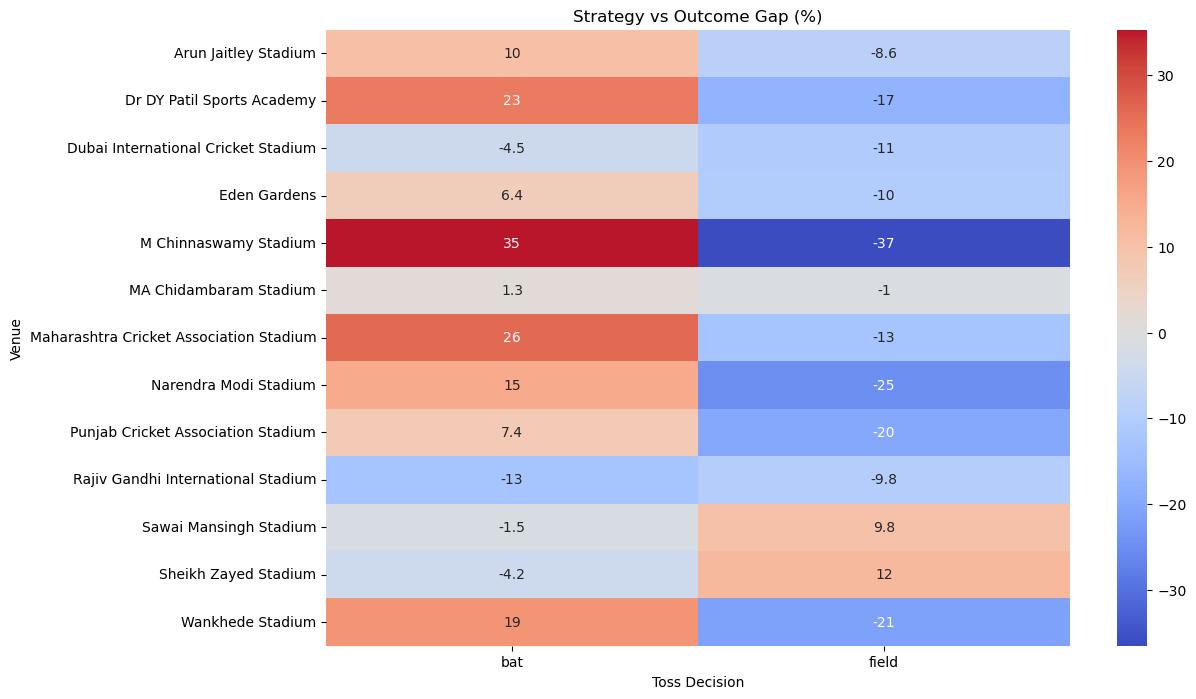

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(gap, annot=True, cmap='coolwarm', center=0)

plt.title("Strategy vs Outcome Gap (%)")
plt.xlabel("Toss Decision")
plt.ylabel("Venue")
plt.show()

In [ ]:
The above Heatmap shows us the gap between the actual win percentage and percentage of times that decision
was taken.
#That is in Narendra modi stadium which shows bat +15 teams teams have underutilised batting first.

In [30]:
toss_advantage = venue_advantage.sort_values(by='win_pct', ascending=False)
print(toss_advantage)


                                         win_pct  matches
venue                                                    
Sharjah Cricket Stadium                     57.1       28
Sawai Mansingh Stadium                      56.2       64
Maharashtra Cricket Association Stadium     54.9       51
Sheikh Zayed Stadium                        54.1       37
Dr DY Patil Sports Academy                  54.1       37
M Chinnaswamy Stadium                       53.5       99
Wankhede Stadium                            52.0      125
Brabourne Stadium                           51.9       27
Arun Jaitley Stadium                        51.5       97
Eden Gardens                                51.0      100
MA Chidambaram Stadium                      50.5       91
Punjab Cricket Association Stadium          47.5       61
Narendra Modi Stadium                       46.7       45
Dubai International Cricket Stadium         43.5       46
Rajiv Gandhi International Stadium          39.8       83


In [31]:
import numpy as np
p = df['toss_match_win'].mean()
n = df['toss_match_win'].count()

se = np.sqrt(p * (1 - p) / n)
ci_low = p - 1.96 * se
ci_high = p + 1.96 * se

print(p, ci_low, ci_high)

0.5158254918733961 0.4871770388078382 0.5444739449389541


In [32]:
venue_win = df.groupby('venue')['toss_match_win'].mean()
print(venue_win.describe())

count    36.000000
mean      0.548965
std       0.159897
min       0.200000
25%       0.458696
50%       0.532383
75%       0.609091
max       1.000000
Name: toss_match_win, dtype: float64


In [40]:
from scipy.stats import ttest_1samp

# Store p-value per venue
p_values = {}
for v in valid_venues:
    data = df[df['venue'] == v]['toss_match_win']
    if len(data) >= 25:
        stat, p = ttest_1samp(data, 0.5)
        p_values[v] = round(p, 4)
    else:
        p_values[v] = None

In [41]:
pref_decision = decision_choice_pct.idxmax(axis=1)
best_decision = decision_win_pct.idxmax(axis=1)


In [42]:
summary = pd.DataFrame({
    'pref_decision': pref_decision,
    'best_decision': best_decision,
    'gap_bat': gap['bat'],
    'gap_field': gap['field'],
    'p_value': p_values
})

In [43]:
def get_insight(row):
    if row['p_value'] > 0.05:
        if row['pref_decision'] != row['best_decision']:
            return "Suboptimal decision"
        else:
            return "No strong impact"
    else:
        return "Statistically significant"

summary['insight'] = summary.apply(get_insight, axis=1)

In [44]:
summary

,pref_decision,best_decision,gap_bat,gap_field,p_value,insight
Arun Jaitley Stadium,field,field,10.5,-8.6,0.7624,No strong impact
Dr DY Patil Sports Academy,field,field,23.0,-17.4,0.6284,No strong impact
Dubai International Cricket Stadium,field,field,-4.5,-10.6,0.3822,No strong impact
Eden Gardens,field,field,6.4,-10.3,0.8426,No strong impact
M Chinnaswamy Stadium,field,field,35.3,-36.5,0.4845,No strong impact
MA Chidambaram Stadium,bat,bat,1.3,-1.0,0.9172,No strong impact
Maharashtra Cricket Association Stadium,field,bat,25.9,-12.7,0.4893,Suboptimal decision
Narendra Modi Stadium,field,field,15.0,-24.8,0.6598,No strong impact
Punjab Cricket Association Stadium,field,field,7.4,-19.8,0.7042,No strong impact
Rajiv Gandhi International Stadium,field,field,-12.8,-9.8,0.0616,No strong impact
